# Neural Networks (MLP) for Regression

__INDEX__
1. [Neural Networks (MLPs)](#neuralnet) <br>
    1.1. [About Neural Networks(MLPs)](#about) <br>

2. [Setup and Data Preparation](#setup)
3. [Model Selection Experiments](#expruns)<br>
    3.1. [Full Feature Set Experiments](#allfeat) <br>
    3.2. [Excluding `previousOwners`+ Log(Price)](#noprevown) <br>
        3.3. [Feature Engineering: Ablations and Additions](#feateng) <br>
            3.3.1 [Original + Feature engineered features + Log(price)+ 65% FS](#featengsel) <br>
            3.3.2 [Age + Excluding `previousOwners`+ Log(Price)](#agenofs) <br>
            3.3.3 [Age + Excluding `previousOwners`+ Log(Price) + 80% FS](#agefs) <br>

4. [Visualization and Final Regards about the Implementation](#visualization)




## 1. Neural Networks (MLPs)
<a id="neuralnet"></a>

### 1.1. About Neural Networks(MLPs)
<a id="about"></a>

Neural networks, specifically Multi-Layer Perceptrons (MLPs), are high-capacity models capable of learning complex, non-linear relationships by combining multiple layers of interconnected neurons. Each neuron applies a non-linear transformation to a weighted combination of its inputs, and the network jointly optimizes these weights to minimize a chosen loss function. Unlike tree-based models, which rely on hierarchical splits, MLPs model the relationship between features and the target variable directly through differentiable transformations.

Training an MLP is an optimization problem solved via backpropagation: the model iteratively adjusts all weights simultaneously to reduce prediction error. Unlike sequential boosting methods, which correct residuals one step at a time, MLPs update all parameters together, which allows them to capture global patterns but can also make optimization more challenging.

Scikit-learn’s MLPRegressor provides a feed-forward neural network implementation for regression, allowing us to control:

- Network architecture: number of hidden layers and neurons per layer, which directly influences the model’s capacity.
- Learning rate and batch size: key parameters for convergence speed and stability.
- Optimization solver (Adam): adaptive gradient optimization.
- Early stopping: prevents overfitting by halting training when validation performance stops improving.

By including MLPs in our experimental setup, we aim to complement tree-based approaches and assess whether a fully non-linear, high-capacity model improves prediction performance. The use of hidden layers enables the network to learn interactions between features that may be difficult to capture with linear models or trees.

## 2. Setup and Preparation
<a id="setup"></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
import time
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import os
import random
import logging
from IPython.display import display

In [ ]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) - np.asarray(y_pred)))


In [4]:
def _normalize_cats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = fill_unknown(df[col])
            df = column_string_transformer(df, column=col, remove_middle_spaces=True, allow_extra_chars="")
    return df

In [5]:
%run 05_0.1_visualization_helpers.ipynb  

c:\Users\Rosa Melo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# All of our preprocessing helper functions are in this notebook
%run 05_0_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# at this point, this are all the features in use 
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']              
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 8 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness
# ---------------------------------------------------------
# 0) CONFIGS GERAIS
# ---------------------------------------------------------
N_SPLITS = 8
N_ITER = 10
RANDOM_STATE = 42


X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 3. Model Selection Experiments (Random Search and 8-Fold CV)  <a id="expruns"></a>

### 3.1. Full Feature Set Experiment <a id="allfeat"></a>

In [ ]:
# we will use an 5-fold cross-validation strategy
N_SPLITS = 5 
RANDOM_STATE = 42
# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

N_RANDOM_CONFIGS = 10 # this is a short random search, enough for baseline results

# we get N_RANDOM_CONFIGS (10) random parameter combinations from param_distributions 
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE 
best_rmse = np.inf 
best_config = None 

# to store our fold results
log_path = "NN_2complete_log.txt"
# Note: this section is mainly for organizational purposes and is not particularly relevant 


with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    # header for the log file - just for readability and general info
    log("# =============================")
    log(f"# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########") 
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")


            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, "mileage", True)
            X_train = transform_mileage_imputer(X_train, mileage_state)
            X_val   = transform_mileage_imputer(X_val,   mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)


            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"] # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train) # fit on training data
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features]) # fit on training data
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            #-------
            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            #----------------
            # here, we log the features name, to keep track of what is being used from the original set
            # but also because the columns increase due to encoding
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            
            # -> Model Training 
            # params contains the hyperparameters for this configuration
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_final, y_train)

            # predictions on train and validation fold
            y_pred_train = mlp_model.predict(X_train_final)
            y_pred_val   = mlp_model.predict(X_val_final)

            # -> Metrics Calculation
            # Training metrics:
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")
            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")


# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(10))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: NN_2complete_log.txt
# =============================

######## CONFIG 1/10 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}

[C1|F1] Processing fold...
  > Features Used (16): ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.8634 | RMSE: 3616 | MAE: 2215 | Bias: 277.4
  > [VAL]   R2: 0.8695 | RMSE: 3448 | MAE: 2233 | Bias: 240.7

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.8586 | RMSE: 3662 | MAE: 2203 | Bias: 427.5
  > [VAL]   R2: 0.8598 | RMSE: 3642 | MAE: 2203 | Bias:

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
7,8,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,3541.975894,2196.098989,0.867635,-39.020119,2184.679394,0.871788,-40.720629,1503.110717
3,4,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,3598.351673,2218.057170,0.863398,174.066072,2210.409403,0.866743,174.295965,1504.440089
5,6,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,3599.308894,2215.313910,0.863335,66.791073,2208.660148,0.866267,66.192216,1499.075714
6,7,adam,25,900,0.010,adaptive,"(256, 128)",True,64,relu,3618.169043,2243.434702,0.861869,91.917749,2234.727105,0.864759,89.618981,1531.293802
4,5,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,3653.295169,2248.879259,0.859191,35.625560,2240.756084,0.862221,37.065897,1537.058418
0,1,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu,3684.723544,2257.776083,0.856709,83.310565,2251.734854,0.860229,80.095036,1527.116432
9,10,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu,3707.659031,2293.999478,0.854913,150.910947,2288.850273,0.858356,148.915741,1582.234835
8,9,adam,25,900,0.010,adaptive,"(128, 64)",True,64,relu,3727.267410,2288.800603,0.853412,66.742078,2286.084242,0.855385,66.405242,1555.678347
1,2,adam,25,900,0.050,adaptive,"(128, 64)",True,128,relu,3766.921720,2316.402214,0.850309,-15.173122,2309.671891,0.853642,-17.687448,1596.360339
2,3,adam,25,900,0.050,adaptive,"(256, 128)",True,64,relu,3880.234772,2429.910958,0.840955,-166.171885,2425.056175,0.844482,-163.608522,1723.660633



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}


### 3.2. Feature Ablation Experiment: Excluding `previousOwners` and Applying a Log-Transformed Target (price) <a id="noprevown"></a>

In [7]:
# we will use an 5-fold cross-validation strategy
N_SPLITS = 5 
RANDOM_STATE = 42
# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "year"]
DROP_FROM_MODEL = ["previousOwners"]
# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

N_RANDOM_CONFIGS = 10 # this is a short random search, enough for baseline results

# we get N_RANDOM_CONFIGS (10) random parameter combinations from param_distributions 
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE 
best_rmse = np.inf 
best_config = None 

# to store our fold results
log_path = "NN_noowners_logprice.txt"
# Note: this section is mainly for organizational purposes and is not particularly relevant 


with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    # header for the log file - just for readability and general info
    log("# =============================")
    log(f"# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########") 
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
            y_train_log = np.log1p(y_train)
            log(f"\n[C{config_id}|F{fold}] Processing fold...")


            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, "mileage", True)
            X_train = transform_mileage_imputer(X_train, mileage_state)
            X_val   = transform_mileage_imputer(X_val,   mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"] # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log) # fit on training data
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features]) # fit on training data
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)


            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model Training 
            # params contains the hyperparameters for this configuration
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_final, y_train_log)

            # predictions on train and validation fold
            y_pred_train_log = mlp_model.predict(X_train_final)
            y_pred_val_log   = mlp_model.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics Calculation
            # Training metrics:
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")
            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")


# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(10))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: NN_noowners_logprice.txt
# =============================

######## CONFIG 1/10 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'year', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9140 | RMSE: 2869 | MAE: 1717 | Bias: -43.6
  > [VAL]   R2: 0.9155 | RMSE: 2774 | MAE: 1741 | Bias: -72.4

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9137 | RMSE: 2862 | MAE: 1679 | Bias: 281.9
  > [VAL]   R2: 0.9087 | RMSE: 2939 | MAE: 1721 | Bias: 318.7

[C1|F3

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
3,4,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,2946.512012,1709.198408,0.908329,216.764191,1672.511276,0.913249,211.839041,1072.498175
7,8,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,2951.047303,1727.584500,0.907787,121.372609,1688.157103,0.915847,116.003556,1086.051946
5,6,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,2957.609350,1727.018963,0.907602,116.435668,1697.933450,0.913307,115.942509,1089.817231
0,1,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu,2962.748504,1742.318536,0.907334,75.327745,1713.324988,0.913331,72.518352,1093.598162
9,10,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu,2976.507480,1716.189685,0.906325,203.353284,1684.856343,0.910433,198.205588,1081.062289
4,5,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,3034.936109,1751.139823,0.902602,187.533700,1715.317939,0.910544,184.727702,1095.221343
6,7,adam,25,900,0.010,adaptive,"(256, 128)",True,64,relu,3070.424853,1783.550613,0.900468,195.549709,1758.115960,0.906402,189.410929,1122.060965
8,9,adam,25,900,0.010,adaptive,"(128, 64)",True,64,relu,3077.619004,1797.036891,0.899834,151.172402,1772.618957,0.904413,146.123475,1133.382638
1,2,adam,25,900,0.050,adaptive,"(128, 64)",True,128,relu,3284.092637,1935.514989,0.886102,135.372093,1931.164040,0.889465,126.136751,1235.050180
2,3,adam,25,900,0.050,adaptive,"(256, 128)",True,64,relu,3401.868448,1997.265228,0.877864,174.679877,1982.069452,0.880370,172.937369,1270.800040



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}


#### 3.3.1. Original and Engineered Features (with Feature Selection of 65%) with Log-Transformed Target (price) <a id="featengsel"></a>

In [ ]:
from sklearn.model_selection import ParameterSampler
numeric_features = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners"]
categorical_features = ["Brand", "model", "transmission", "fuelType"]

N_ITER = 20
FS_KEEP_RATIO = 0.65

RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

LOG_FILE = "random_search_fe_fs_results_rmse_fs65_iter35.log"
logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    filemode="w",
    force=True
)

logging.info(f"{N_ITER} iterations | {N_SPLITS}-fold | FS_KEEP_RATIO={FS_KEEP_RATIO}")

param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

sampler = ParameterSampler(
    param_distributions=param_distributions,
    n_iter=N_ITER,
    random_state=RANDOM_STATE
)

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []
best_rmse = np.inf
best_row = None

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

# separate high and low cardinality categorical features for future encoding steps
high_card_features = ["Brand", "model"] # these for target encoding
low_card_features  = [c for c in categorical_features if c not in high_card_features] # these for one-hot encoding

def eval_one_config(name: str, params: dict) -> dict:
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        # kf.split(X) returns the row indices for the train/validation split of each CV fold
        # fold starts at 1 just for cleaner logging (Fold 1, Fold 2, etc) 

        # Extract fold data by integer position
        # .copy() prevents in-fold transformations from accidentally affecting the original 
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        # train in log space to stabilize variance and therefore reduce target skew 
        # y_log = log(1 + y). then we invert with expm1() to evaluate in currency
        y_train_log = np.log1p(y_train)

        # this was already performed, but just for safety
        X_train = _normalize_cats(X_train)
        X_val   = _normalize_cats(X_val)

        # keep only expected base columns (prevents accidental leakage / extra columns wrongfully added)
        base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
        X_train = X_train[base_cols].copy()
        X_val   = X_val[base_cols].copy()

        # guards
        required = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners", "Brand", "model"]
        missing = [c for c in required if c not in X_train.columns]
        if missing:
            raise KeyError(f"[Fold {fold}] faltam colunas necessárias no pipeline: {missing}")

        # -> Preprocessing Steps 
        # fit is only done with the training data 
        # we aplly the transformations (some obtained through fit) to both train and validation sets
        # all preprocessing functions are explained before, here we just apply them in order
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(X_train, valid_transmissions)
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)


        # -> Feature Engineering
        # replace previousOwners feature with a more robust derived feature (and drop original)
        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

        # age feature: uses a fixed reference year (base_year=2020)
        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

        # mileage-derived features; drops original mileage
        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
    
        # discretize engineSize into bins; treat as categorical (string) for OHE
        X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
        X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

        X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
        low_card_curr = low_card_features + ["engine_bin"]

        # -> Encoding 
        # target encoder fits on train fold using y_train_log (preventing data leakage)
        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train_log)
        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        # One-hot encode low-cardinality categoricals; fits on train fold only
        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_curr])
        X_train_low = ohe.transform(X_train[low_card_curr])
        X_val_low   = ohe.transform(X_val[low_card_curr])

        
        # Numeric columns AFTER feature engineering
        raw_cat_cols = set(high_card_features + low_card_curr)  # Brand, model + low-card (+ engine_bin)
        numeric_curr = [c for c in X_train.columns if c not in raw_cat_cols]

        X_train_num = X_train[numeric_curr]
        X_val_num   = X_val[numeric_curr]

        X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
        X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

        scaler = StandardScaler()
        X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
        X_val_num_te_scaled   = scaler.transform(X_val_num_te)
        
        X_train_num_te_scaled = pd.DataFrame(
            X_train_num_te_scaled,
            columns=X_train_num_te.columns,
            index=X_train.index
        )

        X_val_num_te_scaled = pd.DataFrame(
            X_val_num_te_scaled,
            columns=X_val_num_te.columns,
            index=X_val.index
        )

        X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
        X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

        X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

        #----------------

        # --> Feature Selection
        n_feats = X_train_final.shape[1] # total number of engineered + encoded features available in this fold
        
        # ceil ensures we don't keep fewer features due to rounding
        # clamp to [1, n_feats] guarantees a valid number of selected features
        k = int(np.ceil(FS_KEEP_RATIO * n_feats))
        k = max(1, min(k, n_feats))

        # train a random forest on the train fold only to estimate feature importances
        # We use y_train_log because the main model is trained in log-target space as well
        rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
        rf_fs.fit(X_train_final, y_train_log)

        # SelectFromModel will keep the k most important features
        # threshold = -inf means not filtering by importance threshold
        #   selection is controlled primarily by max_features = k
        # - prefit=True indicates rf_fs is already fitted, so SelectFromModel won't refit it.
        selector = SelectFromModel(
            estimator=rf_fs,
            threshold=-np.inf,
            max_features=k,
            prefit=True
        )

        # Boolean mask of selected features based on rf_fs.feature_importances_
        selected_cols = X_train_final.columns[selector.get_support()]

        # Apply the same selected feature subset to both train and validation folds
        # this ensures a fair validation: the validation data is never used to decide the features
        X_train_sel = X_train_final[selected_cols]
        X_val_sel   = X_val_final[selected_cols]

        # --> train on log target and for prediction invert back to currency
        mlp_model = MLPRegressor(
            hidden_layer_sizes=params["hidden_layer_sizes"],
            activation=params.get("activation"),
            solver=params.get("solver"),
            learning_rate_init=params.get("learning_rate_init"),
            learning_rate=params.get("learning_rate"),
            batch_size=params.get("batch_size", "auto"),
            max_iter=params.get("max_iter"),
            n_iter_no_change=params.get("n_iter_no_change", 25),
            early_stopping=params.get("early_stopping"),
            random_state=42,
            verbose=False
        )
        mlp_model.fit(X_train_sel, y_train_log)

        # predictions (log scale), then invert to original scale
        y_pred_train_log = mlp_model.predict(X_train_sel)
        y_pred_val_log   = mlp_model.predict(X_val_sel)

        pred_tr = np.expm1(y_pred_train_log)
        pred_val   = np.expm1(y_pred_val_log)

        # --> metrics 
        rmse_tr = rmse(y_train, pred_tr)
        rmse_val = rmse(y_val, pred_val)

        mae_tr = float(mean_absolute_error(y_train, pred_tr))
        mae_val = float(mean_absolute_error(y_val, pred_val))

        r2_tr = float(r2_score(y_train, pred_tr))
        r2_val = float(r2_score(y_val, pred_val))

        bias_tr = bias(y_train, pred_tr)
        bias_val = bias(y_val, pred_val)

        fold_rows.append({
            "config": name,
            "fold": fold,
            "n_features_total": int(n_feats),
            "n_features_selected": int(len(selected_cols)),

            "train_rmse": rmse_tr,
            "val_rmse": rmse_val,
            "train_mae": mae_tr,
            "val_mae": mae_val,
            "train_r2": r2_tr,
            "val_r2": r2_val,
            "train_bias": bias_tr,
            "val_bias": bias_val,
        })

    df_folds = pd.DataFrame(fold_rows)

    # mean after folds
    out = {
        "config": name,

        "val_rmse_mean": float(df_folds["val_rmse"].mean()),
        "train_rmse_mean": float(df_folds["train_rmse"].mean()),
        "val_mae_mean": float(df_folds["val_mae"].mean()),
        "train_mae_mean": float(df_folds["train_mae"].mean()),
        "val_r2_mean": float(df_folds["val_r2"].mean()),
        "train_r2_mean": float(df_folds["train_r2"].mean()),
        "val_bias_mean": float(df_folds["val_bias"].mean()),
        "train_bias_mean": float(df_folds["train_bias"].mean()),

        "avg_selected_features": float(df_folds["n_features_selected"].mean()),
        "avg_total_features": float(df_folds["n_features_total"].mean()),
        **params,
    }

    print(
        f"   >> [{name}] "
        f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL R2: {out['val_r2_mean']:.4f} | "
        f"VAL MAE: {out['val_mae_mean']:.1f} | VAL Bias: {out['val_bias_mean']:.1f} | "
        f"Sel: {out['avg_selected_features']:.0f} feats"
    )

    logging.info(
        f"{name} | "
        f"VAL_RMSE={out['val_rmse_mean']:.6f} | VAL_MAE={out['val_mae_mean']:.6f} | "
        f"VAL_R2={out['val_r2_mean']:.6f} | VAL_BIAS={out['val_bias_mean']:.6f} | "
        f"TRAIN_RMSE={out['train_rmse_mean']:.6f} | TRAIN_MAE={out['train_mae_mean']:.6f} | "
        f"SelAvg={out['avg_selected_features']:.3f} | Params={params}"
    )

    return out

for i, params in enumerate(sampler, start=1):
    name = f"CONFIG_{i}"

    if (i - 1) % 5 == 0:
        print(f"\n-- doing {i}/{N_ITER}")

    res = eval_one_config(name, params)
    results.append(res)

    if res["val_rmse_mean"] < best_rmse:
        best_rmse = res["val_rmse_mean"]
        best_row = res

results_df = pd.DataFrame(results)

print("\n- TOP 10 Configurations (sorted by VAL RMSE)")

results_df_sorted = results_df.sort_values(
    "val_rmse_mean", ascending=True
)

display(results_df_sorted.head(10))

OUT_CSV = "random_search_fe_fs_results_rmse_fs65_iter35.csv"
results_df_sorted.to_csv(OUT_CSV, index=False)

print(f"stored at: {OUT_CSV}")
print(f"log in: {LOG_FILE}")

print("\n- BEST CONFIG (by VAL RMSE)")
print(f"Config: {best_row['config']}")
print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
print(f"VAL Bias: {best_row['val_bias_mean']:.3f}")

best_params = {k: best_row[k] for k in param_distributions}
print("Params:")
print(best_params)


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



-- doing 1/20
   >> [CONFIG_1] VAL RMSE: 3382.3 | VAL R2: 0.8793 | VAL MAE: 1999.7 | VAL Bias: 222.0 | Sel: 17 feats
   >> [CONFIG_2] VAL RMSE: 3021.6 | VAL R2: 0.9035 | VAL MAE: 1752.0 | VAL Bias: 165.9 | Sel: 17 feats
   >> [CONFIG_3] VAL RMSE: 2927.7 | VAL R2: 0.9094 | VAL MAE: 1699.4 | VAL Bias: 255.4 | Sel: 17 feats
   >> [CONFIG_4] VAL RMSE: 3388.8 | VAL R2: 0.8788 | VAL MAE: 1975.2 | VAL Bias: 150.0 | Sel: 17 feats
   >> [CONFIG_5] VAL RMSE: 3014.2 | VAL R2: 0.9040 | VAL MAE: 1743.0 | VAL Bias: 197.7 | Sel: 17 feats

-- doing 6/20
   >> [CONFIG_6] VAL RMSE: 2974.3 | VAL R2: 0.9065 | VAL MAE: 1719.9 | VAL Bias: 229.5 | Sel: 17 feats
   >> [CONFIG_7] VAL RMSE: 3238.0 | VAL R2: 0.8893 | VAL MAE: 1907.0 | VAL Bias: 255.9 | Sel: 17 feats
   >> [CONFIG_8] VAL RMSE: 3063.3 | VAL R2: 0.9009 | VAL MAE: 1760.5 | VAL Bias: 74.9 | Sel: 17 feats
   >> [CONFIG_9] VAL RMSE: 2863.6 | VAL R2: 0.9133 | VAL MAE: 1662.0 | VAL Bias: 48.9 | Sel: 17 feats
   >> [CONFIG_10] VAL RMSE: 3214.5 | VAL R2: 

,config,val_rmse_mean,train_rmse_mean,val_mae_mean,train_mae_mean,val_r2_mean,train_r2_mean,val_bias_mean,train_bias_mean,avg_selected_features,avg_total_features,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation
8,CONFIG_9,2863.629134,2703.257494,1662.009814,1616.110544,0.913323,0.922897,48.886485,47.178888,17.0,25.0,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu
11,CONFIG_12,2902.087442,2772.003610,1707.292063,1666.823895,0.910965,0.918831,47.911660,40.165970,17.0,25.0,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu
2,CONFIG_3,2927.709593,2815.942772,1699.369804,1661.732246,0.909401,0.916330,255.441377,255.734090,17.0,25.0,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu
5,CONFIG_6,2974.341485,2883.562411,1719.875378,1696.190609,0.906548,0.912235,229.484045,227.027314,17.0,25.0,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu
10,CONFIG_11,2976.185779,2889.569719,1738.955368,1710.468052,0.906406,0.911914,43.926248,38.961403,17.0,25.0,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu
4,CONFIG_5,3014.188423,2935.684112,1743.038814,1718.737492,0.903961,0.909037,197.743630,192.220660,17.0,25.0,adam,25,900,0.010,adaptive,"(128, 64)",True,64,relu
1,CONFIG_2,3021.562510,3010.401357,1752.018918,1729.074070,0.903502,0.904201,165.886874,165.959886,17.0,25.0,adam,25,900,0.010,adaptive,"(256, 128)",True,64,relu
7,CONFIG_8,3063.349686,2960.980669,1760.453339,1727.683388,0.900902,0.907385,74.936378,78.304640,17.0,25.0,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu
9,CONFIG_10,3214.531108,3145.855003,1887.181529,1865.823286,0.890885,0.895578,76.522320,77.715945,17.0,25.0,adam,25,900,0.050,adaptive,"(128, 64)",True,128,relu
6,CONFIG_7,3237.975996,3199.348934,1906.998649,1895.838103,0.889343,0.892011,255.905590,247.508153,17.0,25.0,adam,25,900,0.050,adaptive,"(256, 128)",True,128,relu


stored at: random_search_fe_fs_results_rmse_fs65_iter35.csv
log in: random_search_fe_fs_results_rmse_fs65_iter35.log

- BEST CONFIG (by VAL RMSE)
Config: CONFIG_9
VAL RMSE: 2863.629
VAL R2:   0.913323
VAL MAE:  1662.010
VAL Bias: 48.886
Params:
{'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.005, 'activation': 'relu', 'solver': 'adam', 'batch_size': 128, 'max_iter': 900, 'learning_rate': 'adaptive', 'early_stopping': True, 'n_iter_no_change': 25}


#### 3.3.2. Combining `age` and Excluding `previousOwners` Features and Applying Log-Transformed Target (price) <a id="agenofs"></a>

In [8]:
# we will use an 5-fold cross-validation strategy
N_SPLITS = 5 
RANDOM_STATE = 42
# shuffles the data, in order to, at least theoretically, have more balanced folds
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]
DROP_FROM_MODEL = ["previousOwners"]
# hyperparameter space that we are going to use to random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}

N_RANDOM_CONFIGS = 10 # this is a short random search, enough for baseline results

# we get N_RANDOM_CONFIGS (10) random parameter combinations from param_distributions 
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] # to store results of each configuration, to store the ranking

# tracking the best configuration according to validation RMSE 
best_rmse = np.inf 
best_config = None 

# to store our fold results
log_path = "NN_noowners_age_logprice.txt"
# Note: this section is mainly for organizational purposes and is not particularly relevant 


with open(log_path, "w", encoding="utf-8") as log_file:

    # this function allows printing the messages to the screen and to the log file 
    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    # header for the log file - just for readability and general info
    log("# =============================")
    log(f"# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    # loop that iterates over each random configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########") 
        log(f"Parameters: {params}")

        # we are storing the metrics for each fold here
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        # for each configuration, we do K-Fold cross-validation
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # data split for the current fold
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
            y_train_log = np.log1p(y_train)
            log(f"\n[C{config_id}|F{fold}] Processing fold...")


            # -> Preprocessing Steps 
            # fit is only done with the training data 
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, "mileage", True)
            X_train = transform_mileage_imputer(X_train, mileage_state)
            X_val   = transform_mileage_imputer(X_val,   mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

             # -> Feature engineering: create age and drop year (do this after all year-based steps)
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # hard guarantee: previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature Encoding
            # applied to categorical features only
            # we separate high cardinality and low cardinality categorical features
            high_card_features = ["Brand", "model"] # target encoding for these
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log) # fit on training data
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features]) # fit on training data
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            ###
            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            ####
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")

            # -> Model Training 
            # params contains the hyperparameters for this configuration
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_final, y_train_log)

            # predictions on train and validation fold
            y_pred_train_log = mlp_model.predict(X_train_final)
            y_pred_val_log   = mlp_model.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics Calculation
            # Training metrics:
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)
            # Validation metrics:
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # logging the metrics of this fold
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")
            # storing the metrics of this fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # after all folds, we calculate the mean metrics across them
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        # logging and storing these results
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        # our best configuration is defined by the best rmse
        # by best, we mean the lowest rmse
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")


# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(10))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF NN SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: NN_noowners_age_logprice.txt
# =============================

######## CONFIG 1/10 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9047 | RMSE: 3021 | MAE: 1746 | Bias: 289.2
  > [VAL]   R2: 0.9104 | RMSE: 2857 | MAE: 1757 | Bias: 243.6

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9134 | RMSE: 2867 | MAE: 1709 | Bias: 11.8
  > [VAL]   R2: 0.9048 | RMSE: 3001 | MAE: 1748 | Bias: 32.4

[C1|F

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
3,4,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,2886.426023,1702.224729,0.911993,6.853546,1665.651141,0.918137,3.039930,1070.338160
7,8,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,2892.688010,1691.007939,0.911656,184.930495,1658.411417,0.917710,182.164643,1058.914984
5,6,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,2936.013876,1721.036311,0.908933,205.765385,1689.003601,0.914436,201.323522,1079.998251
4,5,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,2951.079818,1741.982681,0.907995,85.436126,1709.145308,0.913657,86.222815,1100.685939
9,10,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu,3000.021195,1755.903750,0.904991,120.581702,1731.896158,0.909703,118.434088,1116.595718
0,1,adam,25,900,0.010,adaptive,"(128, 64)",True,128,relu,3014.412562,1749.306947,0.904121,129.331453,1719.578689,0.910496,125.421670,1098.312837
8,9,adam,25,900,0.010,adaptive,"(128, 64)",True,64,relu,3037.332692,1789.159345,0.902464,145.953302,1775.572587,0.905497,143.202935,1124.127608
6,7,adam,25,900,0.010,adaptive,"(256, 128)",True,64,relu,3096.807813,1804.778362,0.898716,202.742727,1789.396693,0.902739,197.904791,1128.112280
1,2,adam,25,900,0.050,adaptive,"(128, 64)",True,128,relu,3254.544619,1925.183923,0.888136,250.771464,1914.732336,0.890307,248.229091,1220.675424
2,3,adam,25,900,0.050,adaptive,"(256, 128)",True,64,relu,3460.240055,2020.038288,0.873632,318.874007,2010.023452,0.876997,307.244910,1277.383698



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}


#### 3.3.3. Combining `age` and Excluding `previousOwners` Features (with Feature Selection of 80%) and Applying a Log-Transformed Target (price) <a id="agefs"></a>

In [9]:
# numeric features used by the model (year is replaced by age; previousOwners is excluded)
numeric_features = ["mileage", "engineSize", "tax", "mpg", "age"]

# shuffles the data, in order to (at least theoretically) have more balanced folds
# we will use an 8-fold cross-validation strategy
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# we explicitly exclude this feature from the model input
DROP_FROM_MODEL = ["previousOwners"]

# feature selection: keep 90% of the final encoded feature space
FS_KEEP_RATIO = 0.80

# RandomForest used only to rank feature importances for SelectFromModel
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# hyperparameter space that we are going to use for random search
# each configuration will get 1 value from each of these lists
param_distributions = {
    # MLP params
    "hidden_layer_sizes": [(256, 128),(128,64)],
    "learning_rate_init": [0.05, 0.01, 0.005],
    "activation": ["relu"],
    "solver": ["adam"],
    "batch_size": [64, 128],
    "max_iter": [900],
    "learning_rate": ["adaptive"],
    "early_stopping": [True],
    "n_iter_no_change": [25]
}


N_RANDOM_CONFIGS = 15  # short random search, enough for baseline results

# we get N_RANDOM_CONFIGS random parameter combinations from param_distributions
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []  # stores results for ranking
best_rmse = np.inf
best_config = None

# log setup (mainly for development and traceability)
log_path = "NN_noowners_age_log_fs.txt"

# Note: this section is included mainly for organizational purposes
with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF NN SEARCH (LOG TARGET + AGE FEATURE + FS 80%)")
    log("# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")

    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr,  fold_maes_tr,  fold_r2s_tr,  fold_bias_tr  = [], [], [], []
        fold_med_ae = []
        fold_nsel = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            # log-transform target for training
            y_train_log = np.log1p(y_train)

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # -> Preprocessing steps (fit only on training fold, apply to both)
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # -> Feature engineering: create age and drop year (do this after all year-based steps)
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # hard guarantee: previousOwners is not used by the model
            X_train = X_train.drop(columns=DROP_FROM_MODEL, errors="ignore")
            X_val   = X_val.drop(columns=DROP_FROM_MODEL, errors="ignore")

            # -> Feature encoding (categorical only)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # fit using log-target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            #-------
            X_train_num = X_train[numeric_features]
            X_val_num   = X_val[numeric_features]

            X_train_num_te = pd.concat([X_train_num, X_train_high], axis=1)
            X_val_num_te   = pd.concat([X_val_num,   X_val_high],   axis=1)

            scaler = StandardScaler()
            X_train_num_te_scaled = scaler.fit_transform(X_train_num_te)
            X_val_num_te_scaled   = scaler.transform(X_val_num_te)
            
            X_train_num_te_scaled = pd.DataFrame(
                X_train_num_te_scaled,
                columns=X_train_num_te.columns,
                index=X_train.index
            )

            X_val_num_te_scaled = pd.DataFrame(
                X_val_num_te_scaled,
                columns=X_val_num_te.columns,
                index=X_val.index
            )

            X_train_final = pd.concat([X_train_num_te_scaled, X_train_low], axis=1)
            X_val_final   = pd.concat([X_val_num_te_scaled,   X_val_low],   axis=1)

            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            #----------------
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features before FS ({len(feature_names)}): {feature_names}")

            # -> Feature selection (keep top 90% features by RF importance)
            n_feats = X_train_final.shape[1]
            k = int(np.ceil(FS_KEEP_RATIO * n_feats))
            k = max(1, min(k, n_feats))

            rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
            rf_fs.fit(X_train_final, y_train_log)

            selector = SelectFromModel(
                estimator=rf_fs,
                threshold=-np.inf,  # keep the top max_features
                max_features=k,
                prefit=True
            )

            selected_cols = X_train_final.columns[selector.get_support()]
            fold_nsel.append(len(selected_cols))

            X_train_sel = X_train_final[selected_cols]
            X_val_sel   = X_val_final[selected_cols]

            if fold == 1:
                log(f"  > Selected features ({len(selected_cols)}/{n_feats}) with FS_KEEP_RATIO={FS_KEEP_RATIO:.2f}")

            # -> Model training (train on log-target)
            mlp_model = MLPRegressor(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                activation=params.get("activation"),
                solver=params.get("solver"),
                learning_rate_init=params.get("learning_rate_init"),
                learning_rate=params.get("learning_rate"),
                batch_size=params.get("batch_size", "auto"),
                max_iter=params.get("max_iter"),
                n_iter_no_change=params.get("n_iter_no_change", 25),
                early_stopping=params.get("early_stopping"),
                random_state=42,
                verbose=False
            )
            mlp_model.fit(X_train_sel, y_train_log)

            # predictions (log scale), then invert to original scale
            y_pred_train_log = mlp_model.predict(X_train_sel)
            y_pred_val_log   = mlp_model.predict(X_val_sel)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # -> Metrics on original scale
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val  = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)

            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr);   fold_rmses_tr.append(rmse_tr);   fold_r2s_tr.append(r2_tr);   fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)

        mean_nsel = float(np.mean(fold_nsel))

        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  Selected features (avg): {mean_nsel:.0f} / {n_feats} (after encoding)")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,

            "fs_keep_ratio": FS_KEEP_RATIO,
            "avg_selected_features": mean_nsel,

            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,

            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,

            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# Results
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
display(results_df_sorted.head(5))

print("\nBest Config found:")
print(best_config)


# =============================
# START OF NN SEARCH (LOG TARGET + AGE FEATURE + FS 80%)
# METRICS ON ORIGINAL SCALE: R2, RMSE, MAE, BIAS
# LOG FILE SAVED TO: NN_noowners_age_log_fs.txt
# =============================

######## CONFIG 1/15 ########
Parameters: {'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.05, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'activation': 'relu'}

[C1|F1] Processing fold...


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  > Features before FS (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > Selected features (12/15) with FS_KEEP_RATIO=0.80
  > [TRAIN] R2: 0.8759 | RMSE: 3447 | MAE: 2006 | Bias: 640.8
  > [VAL]   R2: 0.8830 | RMSE: 3265 | MAE: 2021 | Bias: 596.4

[C1|F2] Processing fold...
  > [TRAIN] R2: -3.1768 | RMSE: 19905 | MAE: 2117 | Bias: 163.7
  > [VAL]   R2: 0.8732 | RMSE: 3463 | MAE: 2023 | Bias: 290.9

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.8904 | RMSE: 3198 | MAE: 2002 | Bias: -148.3
  > [VAL]   R2: 0.8688 | RMSE: 3639 | MAE: 2043 | Bias: -106.8

[C1|F4] Processing fold...
  > [TRAIN] R2: 0.8728 | RMSE: 3463 | MAE: 1991 | Bias: 871.5
  > [VAL]   R2: 0.8608 | RMSE: 3672 | MAE: 2006 | Bias: 908.0

[C1|F5] Processing fold...
  > [TRAIN] R2: 0.8805 | RMSE: 3384 | MAE: 1988 | Bias: 308.3
  > [VAL

,config_id,solver,n_iter_no_change,max_iter,learning_rate_init,learning_rate,hidden_layer_sizes,early_stopping,batch_size,activation,fs_keep_ratio,avg_selected_features,val_rmse,val_mae,val_r2,val_bias,train_mae,train_r2,train_bias,val_med_ae
8,9,adam,25,900,0.005,adaptive,"(256, 128)",True,128,relu,0.8,12.0,2868.569244,1684.715769,0.913112,131.676660,1647.072820,0.919300,124.326702,1061.924668
11,12,adam,25,900,0.005,adaptive,"(128, 64)",True,128,relu,0.8,12.0,2919.361001,1716.563341,0.909992,73.506544,1685.455505,0.915586,64.159191,1080.290106
2,3,adam,25,900,0.005,adaptive,"(256, 128)",True,64,relu,0.8,12.0,2962.864599,1731.605320,0.907268,121.427632,1698.260995,0.913379,117.879746,1084.827957
5,6,adam,25,900,0.005,adaptive,"(128, 64)",True,64,relu,0.8,12.0,2992.455346,1732.322023,0.905477,141.026558,1701.898060,0.911355,140.964589,1080.119853
7,8,adam,25,900,0.010,adaptive,"(256, 128)",True,128,relu,0.8,12.0,2995.324054,1751.678743,0.905220,121.734913,1719.244961,0.912165,114.080858,1110.322308



Best Config found:
{'solver': 'adam', 'n_iter_no_change': 25, 'max_iter': 900, 'learning_rate_init': 0.005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 128, 'activation': 'relu'}


### 4. Visualization
<a id="visualization"></a>

### 4.1. Visualizing the Model Performance and Feature Importance <a id="visualization"></a>

- training nn (log-price)


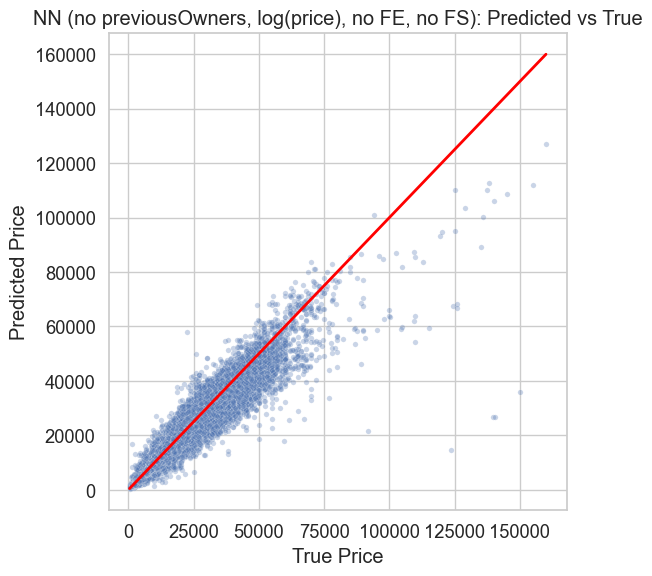

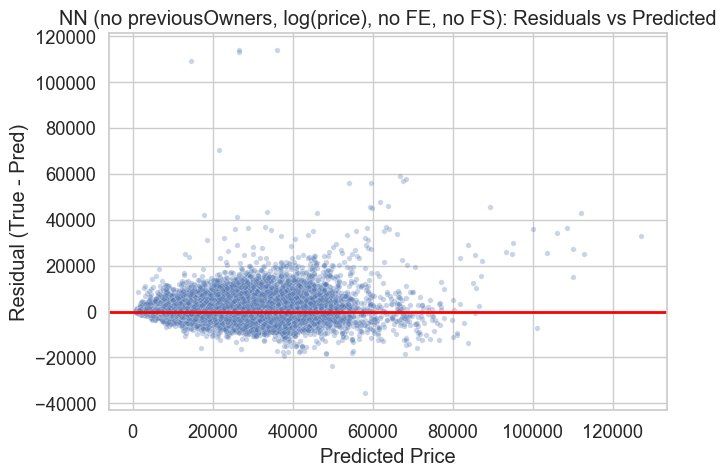

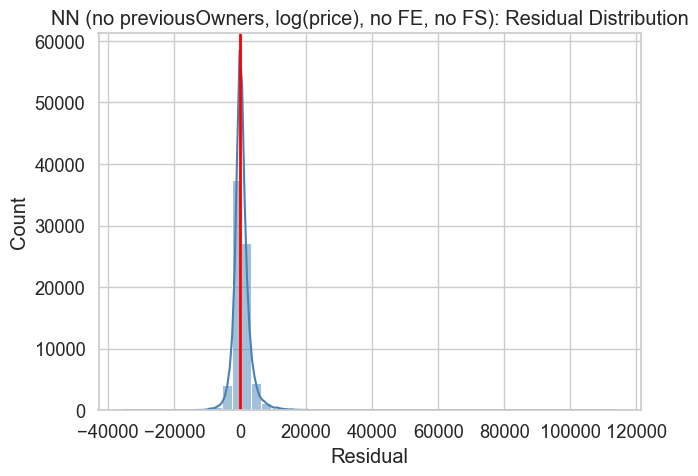

In [7]:
# -----------------------------
# 1) Best config (your chosen one)
# -----------------------------
params = {
    "hidden_layer_sizes": (256, 128),
    "learning_rate_init": 0.005,
    "activation": "relu",
    "solver": "adam",
    "batch_size": 64,
    "max_iter": 900,
    "learning_rate": "adaptive",
    "early_stopping": True,
    "n_iter_no_change": 25
}

MODEL_NAME = "NN (no previousOwners, log(price), no FE, no FS)"

# -----------------------------
# 2) Build FULL training matrix for this setting
#    (same logic as the CV loop, but fit on ALL data)
# -----------------------------
numeric_features = ["year", "mileage", "engineSize", "tax", "mpg"]  # previousOwners excluded
categorical_features = ["Brand", "model", "transmission", "fuelType"]

X_full = X.copy()
y_full = y.copy()

# ensure previousOwners never enters the pipeline
X_full = X_full.drop(columns=["previousOwners"], errors="ignore")

# log target (train in log-space)
y_full_log = np.log1p(y_full)

# ---- Preprocessing (fit on full data, transform on full data) ----
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full,
    valid_brands=valid_brands,
    brand_col="Brand",
    model_col="model",
    year_col="year",
)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(
    train_df=X_full,
    valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand",
    model_col="model",
    year_col="year",
    fuel_col="fuelType",
    mpg_col="mpg",
)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(
    train_df=X_full,
    valid_transmissions=valid_transmissions,
    transm_col="transmission",
    brand_col="Brand",
    model_col="model",
    fuel_col="fuelType",
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full,
    valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType",
    brand_col="Brand",
    model_col="model",
    transm_col="transmission",
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

# ---- Encoding (TE for Brand+model, OHE for the rest) ----
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_log)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

#------------------
# ---- Numeric + Target-encoded features ----
X_full_num_te = pd.concat([X_full[numeric_features], X_full_high], axis=1)

# Apply standard scaling
scaler = StandardScaler()
X_full_num_te_scaled = scaler.fit_transform(X_full_num_te)

# Turn it back into a DataFrame
X_full_num_te_scaled_df = pd.DataFrame(
    X_full_num_te_scaled,
    index=X_full.index,
    columns=X_full_num_te.columns
)

X_full_sel = pd.concat([X_full_num_te_scaled_df, X_full_low], axis=1)

# -----------------------------
# 3) Fit FINAL model on FULL data (log-space)
# -----------------------------
mlp_model = MLPRegressor(
    hidden_layer_sizes=params["hidden_layer_sizes"],
    activation=params.get("activation"),
    solver=params.get("solver"),
    learning_rate_init=params.get("learning_rate_init"),
    learning_rate=params.get("learning_rate"),
    batch_size=params.get("batch_size", "auto"),
    max_iter=params.get("max_iter"),
    n_iter_no_change=params.get("n_iter_no_change", 25),
    early_stopping=params.get("early_stopping"),
    random_state=42,
    verbose=False
)

print("- training nn (log-price)")
mlp_model.fit(X_full_sel, y_full_log)

# -----------------------------
# 4) Run ALL visualizations for this best model
# -----------------------------
plot_pred_vs_true_fs(mlp_model, MODEL_NAME)
plot_residuals_fs(mlp_model, MODEL_NAME)
plot_residual_distribution_fs(mlp_model, MODEL_NAME)

C:\Users\Rosa Melo\AppData\Local\Temp\ipykernel_31112\4128551160.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


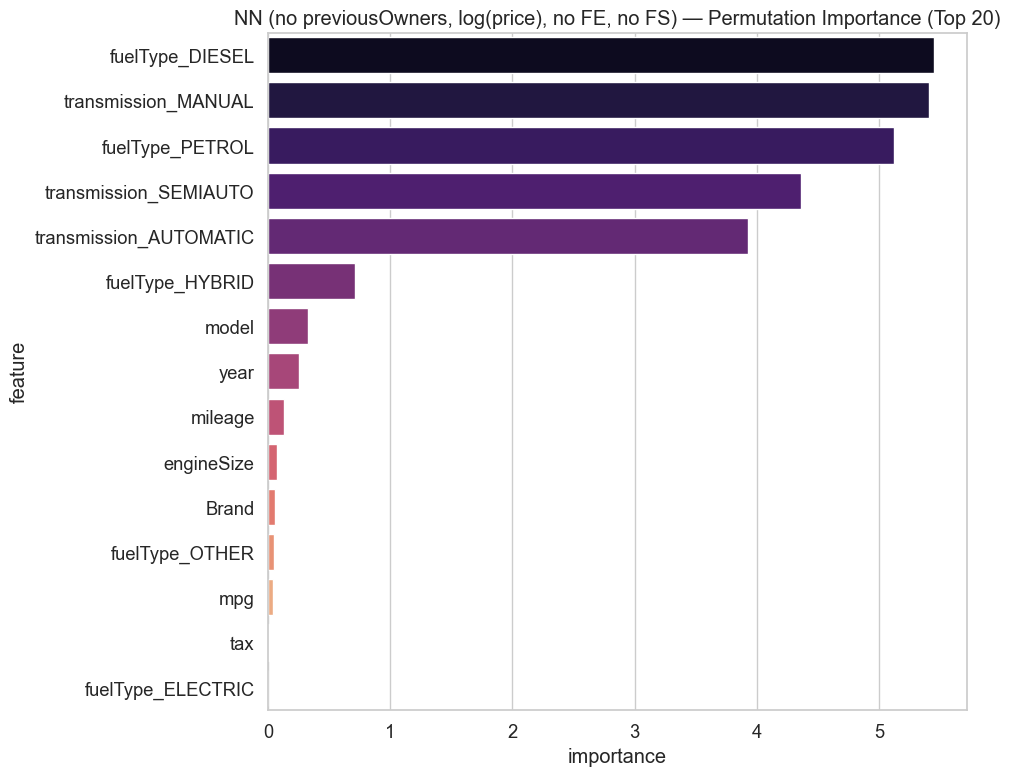

In [8]:
plot_permutation_importance_fs(mlp_model, MODEL_NAME, n_repeats=5, top=20)

  0%|          | 0/2000 [00:00<?, ?it/s]


SHAP for NN (no previousOwners, log(price), no FE, no FS) (sample size = 2000)


/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_7514/2697768544.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)


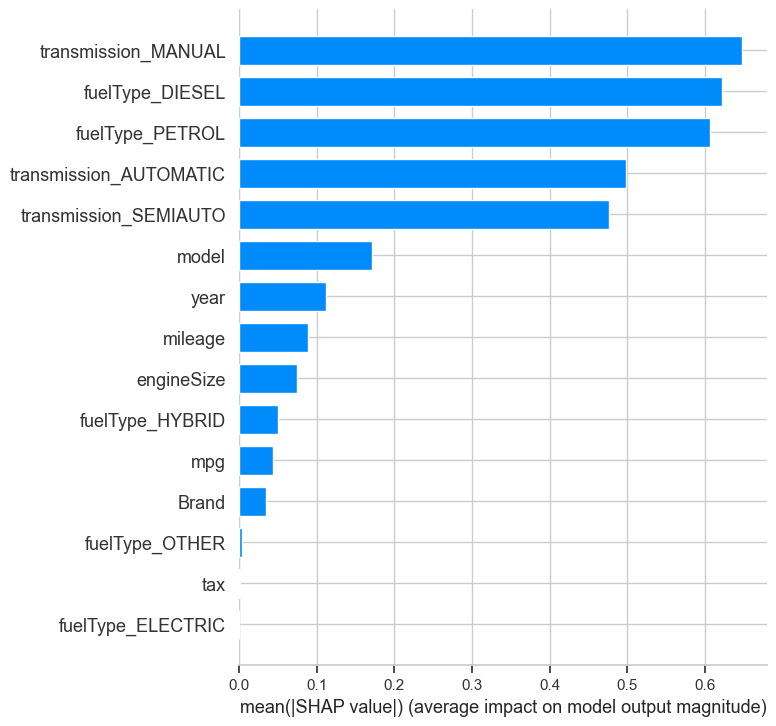

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_7514/2697768544.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=True)


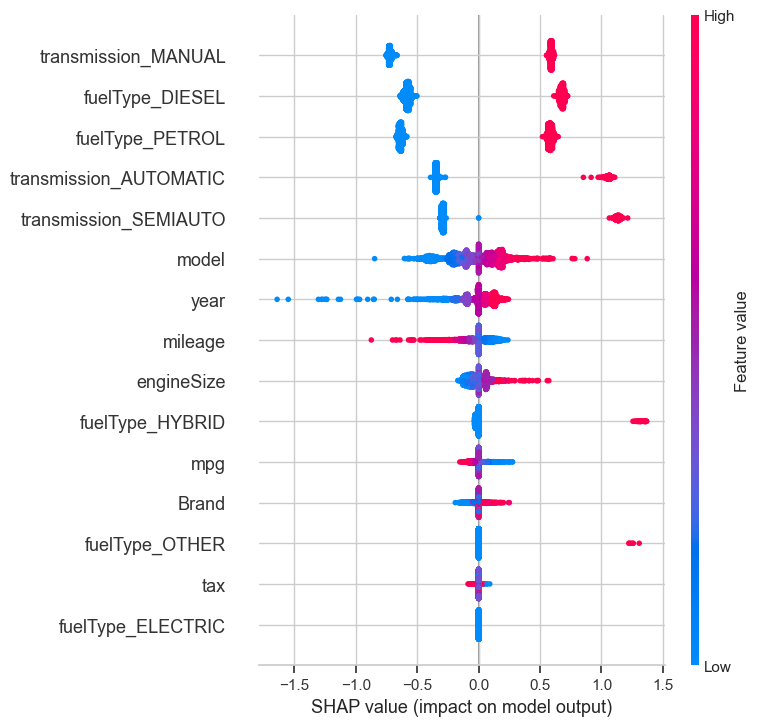

In [17]:
apply_shap_fs(mlp_model, X_full_sel, model_name=MODEL_NAME, sample_size=2000)

### 4.2. Results Obtained and Overall Performance Discussion <a id="result"></a>

The best-performing MLP configuration achieved an RMSE of approximately 2863 and an MAE of approximately 1662 on the validation dataset. This result was obtained using the original features augmented with a subset of engineered features, a log-transformed target variable, and retaining only the 65% most important features (Section 3.3.1). 

In contrast, the baseline MLP trained on the full dataset without feature selection or feature engineering (Section 3.1) performed significantly worse, with an RMSE of approximately 3541 and an MAE of approximately 2196. This marked performance gap highlights the strong dependence of neural networks on informative feature representations and careful preprocessing. Unlike tree-based models, which can naturally exploit raw feature interactions and handle heterogeneous data distributions, MLPs benefit considerably from explicit feature engineering and transformations that simplify the underlying relationships.

Despite the relatively weak predictive performance, the neural network did not exhibit strong overfitting, as the difference between training and validation metrics remained limited. This suggests that model capacity was not excessive and that poor generalization was not the primary cause of the observed performance limitations.

The inferior results obtained with the MLP are consistent with well-known challenges associated with applying neural networks to tabular regression problems. Although neural networks are theoretically capable of modeling complex non-linear relationships, training involves optimizing a highly non-convex loss surface, which may lead to convergence towards sub-optimal solutions. Furthermore, MLPs are highly sensitive to hyperparameter choices such as learning rate, network architecture, and batch size, small deviations from well-tuned values can significantly impair learning. Their strong reliance on well-scaled and carefully preprocessed inputs further increases their fragility when compared to tree-based models.

About the visualizations:

- The *Predicted vs True Price* plot shows good alignment for lower-priced cars, but as prices increase the predictions systematically fall below the diagonal, indicating consistent underestimation for medium and high-value vehicles.
- Residuals are centered around zero for lower predictions but become increasingly positive and more dispersed for higher predicted prices, revealing growing uncertainty and underestimation as price increases.
- The *Residual Distribution* plot shows that residuals are strongly concentrated around zero but exhibit a long positive tail, indicating the presence of large underestimation errors that affect the RMSE, proving our previous point. 
- The permutation importance analysis shows that the model relies mainly on fuel type and transmission features, while numerical variables such as year, mileage, and engine size contribute relatively little to the overall predictive performance.
- The SHAP summary plot indicates that higher values of year and engine size generally increase the predicted price, whereas higher mileage decreases it, although the overall influence of numerical features remains limited when compared to categorical ones.
- Finally, the mean absolute SHAP values confirm that categorical features dominate the model’s predictions, suggesting that the model struggles to extract strong and consistent signals from continuous variables.